# 03 — Gear Estimation Analysis
## Vehicle Telematics Project

**What this notebook does:**
- Estimates gear position using KMeans on RPM/speed ratio — per vehicle
- Validates gear estimates: Gear 1 should have highest RPM, Gear 6 highest speed
- Visualizes KPL and speed per estimated gear per vehicle
- Exports gear estimates to `data/processed/gear_analysis.csv`

**Key insight:** OBD data has no gear sensor. We derive gear from:
```
gear_ratio = RPM / speed
```
Higher ratio = lower gear. Each vehicle is clustered independently.

**Requires:** Run `01_data_cleaning.ipynb` first.

**Author:** Paşan Sancak · [LinkedIn](https://linkedin.com/in/pasansancak) · [GitHub](https://github.com/pasansancak)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, json
sys.path.append('..')
from src.features import add_gear_estimates
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../outputs', exist_ok=True)
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style='darkgrid', palette='muted')

df       = pd.read_parquet('../data/processed/clean.parquet')
EXCLUDED = json.load(open('../data/processed/excluded_devices.json'))

print(f'Loaded  : {len(df):,} rows')
print(f'Excluded: {[int(d) for d in EXCLUDED]}')

Loaded  : 3,021,632 rows
Excluded: [0, 1, 2, 4, 11, 14, 7]


## 1. Estimate Gears (KMeans per vehicle)

In [2]:
# Filter to active driving only
df_gear = df[
    (df['speed'] > 2) &
    (df['rpm'] > 500) &
    (~df['deviceID'].isin(EXCLUDED))
].copy()

# apply KMeans gear estimation — calibrated per vehicle
df_gear = add_gear_estimates(df_gear, EXCLUDED)

# Convert integer gear to label for plotting
df_gear['gear_label'] = 'Gear ' + df_gear['est_gear'].astype(str)

print(f'Vehicles analysed: {df_gear["deviceID"].nunique()}')
print(f'Gear distribution:')
print(df_gear['gear_label'].value_counts().sort_index().to_string())

Vehicles analysed: 8
Gear distribution:
gear_label
Gear 1     18402
Gear 2     36522
Gear 3     98859
Gear 4    351872
Gear 5    440443
Gear 6    636429


## 2. Validation — Check Gear Order Makes Sense

In [3]:
# Gear 1 should have: lowest speed, highest RPM, lowest gear_ratio denominator
# Gear 6 should have: highest speed, lowest RPM/speed ratio
gear_check = df_gear.groupby('est_gear')[['speed', 'rpm', 'gear_ratio', 'kpl']].mean().round(2)
gear_check.index.name = 'gear'
print('Gear validation — mean values per gear (should increase with gear number):')
print(gear_check.to_string())
print()
print('✓ Speed should increase from Gear 1 → 6')
print('✓ gear_ratio should decrease from Gear 1 → 6')

Gear validation — mean values per gear (should increase with gear number):
      speed      rpm  gear_ratio    kpl
gear                                   
1      3.08   942.75      306.16   1.15
2      4.55   933.33      210.84   1.75
3      7.97  1030.86      133.85   2.63
4     16.60  1168.07       74.05   4.57
5     28.34  1281.76       47.90   7.30
6     55.03  1501.93       29.91  11.77

✓ Speed should increase from Gear 1 → 6
✓ gear_ratio should decrease from Gear 1 → 6


## 3. KPL & Speed per Gear — Per Vehicle

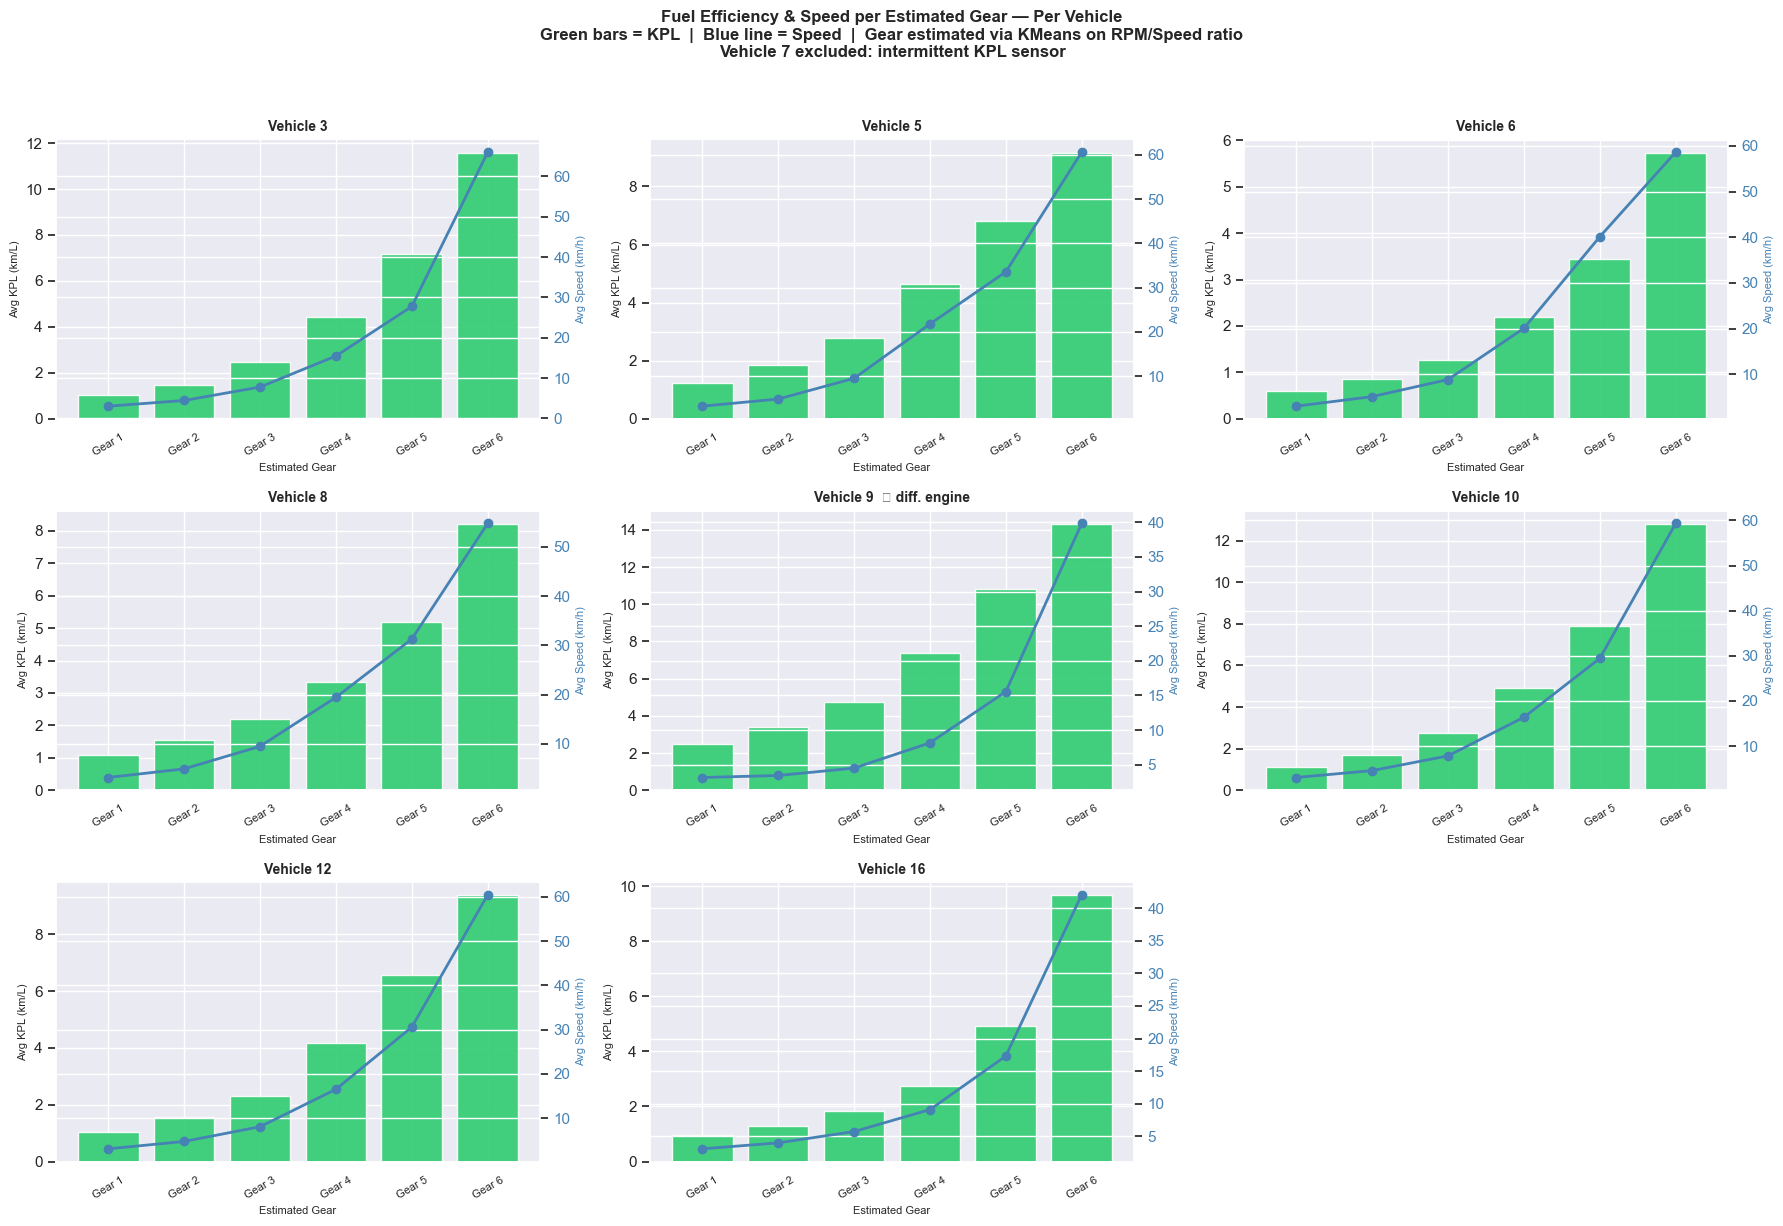

Saved -> outputs/03_gear_analysis.png


In [4]:
gear_order = ['Gear 1','Gear 2','Gear 3','Gear 4','Gear 5','Gear 6']

gear_plot = df_gear.groupby(['deviceID','gear_label'])[['speed','rpm','kpl']].mean().round(2).reset_index()
gear_plot['gear_label'] = pd.Categorical(gear_plot['gear_label'], categories=gear_order, ordered=True)
gear_plot = gear_plot.sort_values(['deviceID','gear_label'])

devices_valid = sorted(df_gear['deviceID'].unique())
n_cols = 3
n_rows = -(-len(devices_valid) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, dev_id in enumerate(devices_valid):
    ax  = axes[i]
    dev = gear_plot[gear_plot['deviceID'] == dev_id]
    if dev.empty:
        continue

    ax.bar(dev['gear_label'], dev['kpl'],
           color='#2ecc71', edgecolor='white', alpha=0.9, label='KPL')

    ax2 = ax.twinx()
    ax2.plot(dev['gear_label'], dev['speed'],
             color='steelblue', marker='o', linewidth=2, label='Speed')
    ax2.set_ylabel('Avg Speed (km/h)', color='steelblue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='steelblue')

    note = '  ⚠ diff. engine' if dev_id == 9.0 else ''
    ax.set_title(f'Vehicle {int(dev_id)}{note}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Estimated Gear', fontsize=8)
    ax.set_ylabel('Avg KPL (km/L)', fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Fuel Efficiency & Speed per Estimated Gear — Per Vehicle\n'
    'Green bars = KPL  |  Blue line = Speed  |  Gear estimated via KMeans on RPM/Speed ratio\n'
    'Vehicle 7 excluded: intermittent KPL sensor',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('../outputs/03_gear_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> outputs/03_gear_analysis.png')

## 4. Export

In [5]:
gear_plot.to_csv('../data/processed/gear_analysis.csv', index=False)

# Export df_gear with est_gear column for use in model notebook
df_gear[['tripID','deviceID','timeStamp','speed','rpm','eLoad','tPos',
         'kpl','cTemp','gear_ratio','est_gear']].to_parquet(
    '../data/processed/with_gears.parquet', index=False
)

print('Exported gear_analysis.csv ✓')
print('Exported with_gears.parquet ✓')

Exported gear_analysis.csv ✓
Exported with_gears.parquet ✓
